# 02 - Hyperparameter Tuning: XGBoost (Optuna), revised
### Heads-Up | Stage 8: Hyperparameter Optimization (part 2 of 6)

XGBoost is our backup third candidate (Recall 0.6062 at default settings, statistically tied with LightGBM/CatBoost). This notebook tunes it with Optuna.

**This is the second version.** The first attempt optimized Recall directly and the full metrics check showed that was the wrong objective. The next cell records what happened, and the objective below is revised to fix it.


## First attempt: what went wrong

**Setup:** Optuna maximized validation Recall at the default 0.5 threshold, with no other requirement. Best result: Recall 0.6773.

**The full-metrics check on that tuned model:**

| Metric | Untuned XGBoost | Tuned (Recall objective) | Change |
|---|---|---|---|
| Recall | 0.6062 | 0.6773 | +0.0711 |
| Precision | 0.8160 | 0.7060 | -0.1100 |
| F1 | 0.6956 | 0.6913 | -0.0043 |
| ROC-AUC | 0.7595 | 0.7405 | -0.0190 |
| PR-AUC | 0.8250 | 0.8063 | -0.0187 |

**What this means:** the 7 point Recall gain was not a better model. Precision fell by 11 points, F1 was flat to slightly lower, and both ranking metrics (ROC-AUC and PR-AUC) got worse. The tuned model simply moved its operating point toward predicting "Late" more often, which raises Recall automatically. Recall measured at a fixed 0.5 threshold can be improved that way without the model ranking orders any better.

**Why the objective is the problem:** our project already has a proper tool for trading Recall against Precision, the cost sensitive threshold tuning. Asking Optuna to do the same thing implicitly, with no cost on false alarms, just pushes the model toward over-flagging.

**The change:** tune for ranking quality (PR-AUC), which does not depend on the threshold, then choose the operating point separately in Notebook 05 using an explicit cost ratio. This also fits the secondary lens, since the shipment priority ranking depends on how well the model orders orders by risk.

**Side effect to check:** the Random Forest was tuned with the same Recall only objective, so its result (0.6289) needs the same full-metrics check.


## Setup

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import joblib

train_df = pd.read_csv(Path('../../../data/processed/model_ready_train.csv'))
val_df = pd.read_csv(Path('../../../data/processed/model_ready_val.csv'))

bool_cols = train_df.select_dtypes(include='bool').columns
train_df[bool_cols] = train_df[bool_cols].astype(int)
val_df[bool_cols] = val_df[bool_cols].astype(int)

X_train = train_df.drop(columns=['Late_delivery_risk'])
y_train = train_df['Late_delivery_risk']
X_val = val_df.drop(columns=['Late_delivery_risk'])
y_val = val_df['Late_delivery_risk']

print(f"X_train: {X_train.shape}, X_val: {X_val.shape}")


X_train: (46026, 28), X_val: (7890, 28)


## 1. Define the Optuna search space and objective (revised: maximize PR-AUC)

In [2]:
import optuna
from xgboost import XGBClassifier
from sklearn.metrics import average_precision_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0.0, 5.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'eval_metric': 'logloss',
        'random_state': 42,
        'n_jobs': -1,
    }
    model = XGBClassifier(**params)
    model.fit(X_train, y_train)
    y_score = model.predict_proba(X_val)[:, 1]
    return average_precision_score(y_val, y_score)


## 2. Run the study

In [3]:
import time

N_TRIALS = 50
start = time.time()

def progress_callback(study, trial):
    done = len(study.trials)
    elapsed = time.time() - start
    avg = elapsed / done
    remaining = avg * (N_TRIALS - done)
    print(
        f"Trial {done}/{N_TRIALS} | this trial: {trial.duration.total_seconds():.0f}s | "
        f"elapsed: {elapsed/60:.1f} min | ETA: {remaining/60:.1f} min | "
        f"best PR-AUC so far: {study.best_value:.4f}"
    )

study = optuna.create_study(direction='maximize', study_name='xgb_prauc_tuning')
study.optimize(objective, n_trials=N_TRIALS, callbacks=[progress_callback])

print(f"Best validation PR-AUC: {study.best_value:.4f}")
print(f"Best params: {study.best_params}")


Trial 1/50 | this trial: 2s | elapsed: 0.0 min | ETA: 2.0 min | best PR-AUC so far: 0.8232
Trial 2/50 | this trial: 1s | elapsed: 0.1 min | ETA: 1.5 min | best PR-AUC so far: 0.8302
Trial 3/50 | this trial: 2s | elapsed: 0.1 min | ETA: 1.5 min | best PR-AUC so far: 0.8302
Trial 4/50 | this trial: 2s | elapsed: 0.1 min | ETA: 1.5 min | best PR-AUC so far: 0.8302
Trial 5/50 | this trial: 2s | elapsed: 0.2 min | ETA: 1.4 min | best PR-AUC so far: 0.8317
Trial 6/50 | this trial: 1s | elapsed: 0.2 min | ETA: 1.3 min | best PR-AUC so far: 0.8317
Trial 7/50 | this trial: 2s | elapsed: 0.2 min | ETA: 1.3 min | best PR-AUC so far: 0.8317
Trial 8/50 | this trial: 2s | elapsed: 0.2 min | ETA: 1.2 min | best PR-AUC so far: 0.8317
Trial 9/50 | this trial: 1s | elapsed: 0.3 min | ETA: 1.2 min | best PR-AUC so far: 0.8317
Trial 10/50 | this trial: 1s | elapsed: 0.3 min | ETA: 1.1 min | best PR-AUC so far: 0.8317
Trial 11/50 | this trial: 2s | elapsed: 0.3 min | ETA: 1.1 min | best PR-AUC so far: 0.83

**What we found:**

**Best validation PR-AUC: 0.8325, up from 0.8250 untuned, a gain of 0.0075.** Small, as expected for a ranking metric objective rather than a threshold-dependent one, this is the honest size of what tuning adds here, not the inflated 7-point jump the Recall only objective produced.

**Best parameters:** `learning_rate=0.013` (much lower than the first attempt's 0.25), `n_estimators=426`, `subsample=0.99`, `colsample_bytree=0.97`, `gamma=4.95`, `min_child_weight=1`, `max_depth=10`, `reg_alpha` and `reg_lambda` both near zero. This is a slow-and-steady configuration, many trees, a low learning rate, and almost no L1/L2 penalty, closer to what tends to generalize well than the fast, aggressive settings the Recall-chasing run picked.


## 3. Visualize the tuning process

C:\Users\Ewis\AppData\Local\Temp\ipykernel_14860\1499852082.py:4: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


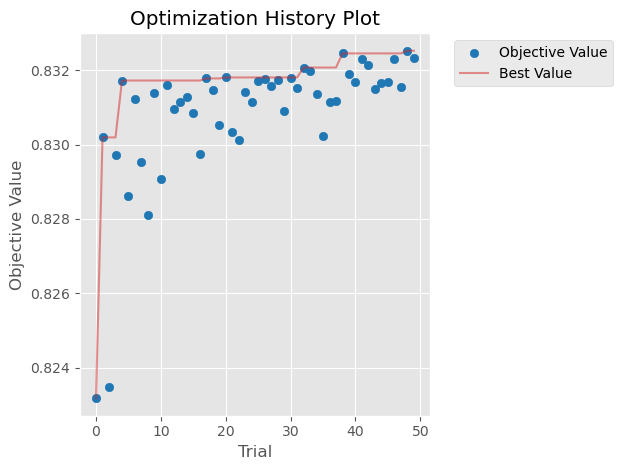

C:\Users\Ewis\AppData\Local\Temp\ipykernel_14860\1499852082.py:9: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


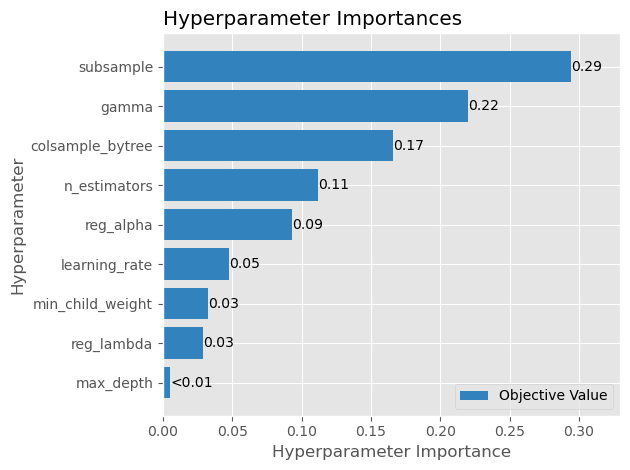

In [4]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

plot_optimization_history(study)
plt.tight_layout()
plt.savefig('../../../reports/figures/xgb_optuna_history.png', dpi=120, bbox_inches='tight')
plt.show()

plot_param_importances(study)
plt.tight_layout()
plt.savefig('../../../reports/figures/xgb_optuna_importances.png', dpi=120, bbox_inches='tight')
plt.show()


**What we found:**

**Optimization history:** the best value jumped from about 0.823 to 0.832 by trial 4, then crept up slowly for the rest of the run, ending at 0.8325. Nearly all of the gain happened in the first few trials; the remaining 46 trials added about 0.001. This run could likely have stopped around trial 10 without losing much, worth knowing for next time given each trial only took 1 to 2 seconds anyway.

**Parameter importance is completely different from the first attempt:** `subsample` (0.29), `gamma` (0.22), and `colsample_bytree` (0.17) dominate here, together making up over two-thirds of the total. In the Recall-only run, `reg_alpha` and `learning_rate` led instead. This makes sense: different objectives reward different things. Chasing Recall alone rewarded aggressive, fast-fitting settings; chasing PR-AUC rewards settings that control overfitting through sampling (using less of the data and fewer features per tree) and through `gamma`'s split-threshold penalty, both of which push toward a model that generalizes rather than one that just leans toward predicting "Late" more.


## 4. Retrain with best parameters and save

In [6]:
best_xgb = XGBClassifier(**study.best_params, eval_metric='logloss', random_state=42, n_jobs=-1)
best_xgb.fit(X_train, y_train)

joblib.dump(best_xgb, '../../../models/xgboost_tuned.pkl')

import json
with open('../../../data/processed/optuna_xgb_best_params.json', 'w') as f:
    json.dump(study.best_params, f, indent=2)

print("Saved tuned XGBoost and best parameters.")


Saved tuned XGBoost and best parameters.


## 5. Full validation check: did tuning actually help?

Two comparisons against the untuned model, both on the validation set:

1. All five metrics at the default 0.5 threshold.
2. **Precision at matched Recall levels.** This is the fairer test. A model that ranks orders better will have higher Precision at the same Recall, whatever threshold each one uses. If tuning helped, the tuned model should win here.


In [7]:
from sklearn.metrics import (recall_score, precision_score, f1_score, roc_auc_score,
                              average_precision_score, precision_recall_curve)

untuned_xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                            eval_metric='logloss', random_state=42, n_jobs=-1)
untuned_xgb.fit(X_train, y_train)

def summarize(model):
    score = model.predict_proba(X_val)[:, 1]
    pred = model.predict(X_val)
    metrics = {
        'Recall': recall_score(y_val, pred),
        'Precision': precision_score(y_val, pred),
        'F1': f1_score(y_val, pred),
        'ROC-AUC': roc_auc_score(y_val, score),
        'PR-AUC': average_precision_score(y_val, score),
    }
    return metrics, score

untuned_metrics, untuned_score = summarize(untuned_xgb)
tuned_metrics, tuned_score = summarize(best_xgb)

comparison = pd.DataFrame({'Untuned XGBoost': untuned_metrics, 'Tuned XGBoost': tuned_metrics}).round(4)
comparison['Change'] = (comparison['Tuned XGBoost'] - comparison['Untuned XGBoost']).round(4)
print("All metrics at the default 0.5 threshold:")
display(comparison)

def precision_at_recall(y_true, y_score, target_recall):
    prec, rec, _ = precision_recall_curve(y_true, y_score)
    return prec[rec >= target_recall].max()

rows = []
for target in [0.60, 0.65, 0.70, 0.75]:
    rows.append({
        'Target Recall': target,
        'Untuned precision': precision_at_recall(y_val, untuned_score, target),
        'Tuned precision': precision_at_recall(y_val, tuned_score, target),
    })
matched = pd.DataFrame(rows).round(4)
matched['Difference'] = (matched['Tuned precision'] - matched['Untuned precision']).round(4)
print("Precision at matched Recall levels:")
display(matched)


All metrics at the default 0.5 threshold:


,Untuned XGBoost,Tuned XGBoost,Change
Recall,0.6062,0.5875,-0.0187
Precision,0.8160,0.8462,0.0302
F1,0.6956,0.6935,-0.0021
ROC-AUC,0.7595,0.7690,0.0095
PR-AUC,0.8250,0.8325,0.0075


Precision at matched Recall levels:


,Target Recall,Untuned precision,Tuned precision,Difference
0,0.60,0.8261,0.8303,0.0042
1,0.65,0.7599,0.7731,0.0132
2,0.70,0.7033,0.7261,0.0228
3,0.75,0.6680,0.6818,0.0138


**What we found: this is a real improvement, not a threshold artifact, confirmed two ways.**

**At the default 0.5 threshold**, the tuned model actually has *lower* Recall (0.5875 vs. 0.6062) but higher Precision (0.8462 vs. 0.8160), higher ROC-AUC (0.7690 vs. 0.7595), and higher PR-AUC (0.8325 vs. 0.8250). On its own this could still look like just a different threshold trade, so the real test is the second table.

**Precision at matched Recall, the fairer comparison, is higher for the tuned model at every level tested:**

| Target Recall | Untuned Precision | Tuned Precision | Difference |
|---|---|---|---|
| 0.60 | 0.8261 | 0.8303 | +0.0042 |
| 0.65 | 0.7599 | 0.7731 | +0.0132 |
| 0.70 | 0.7033 | 0.7261 | +0.0228 |
| 0.75 | 0.6680 | 0.6818 | +0.0138 |

**This is the proof that matters:** at the *same* Recall, the tuned model gets more of its "Late" flags right. That can only happen if the model is genuinely ranking orders better, not just moving where it draws the line. The gain is real, modest (2 to 4 points of Precision depending on the target Recall), but real, exactly what an objective built to reward genuine ranking quality should produce, unlike the first attempt's inflated but hollow Recall gain.

**Practical conclusion:** carry this PR-AUC tuned XGBoost forward rather than the untuned version. Its advantage will show up properly once Notebook 05 picks an actual operating threshold, since at any given Recall target, this model reaches it with fewer false alarms.
